# Heart Disease Diagnostic Classification

###  Overview
The goal of this project is to build a machine learning system to predict the presence of heart disease in patients based on clinical features. We are comparing **Logistic Regression** (baseline) and **Random Forest** (complex) to determine which model offers the best balance of precision and recall.

###  Medical Logic & Constraints
In this diagnostic context, **Recall** is our most critical metric. Missing a sick patient (False Negative) is much more dangerous than a False Positive. This project implements:
* **Stratified Splitting:** Ensuring the proportion of sick vs. healthy patients is consistent across train/test sets.
* **Scikit-Learn Pipelines:** Preventing **Data Leakage** by strictly separating preprocessing from model training.
* **Class Weights:** Addressing any potential imbalance in the target variable.

###  Dataset Source
The data used is the **UCI Heart Disease Dataset**, containing 303 patient records with 14 clinical attributes (age, sex, chest pain type, cholesterol, etc.).

In [1]:
# All the necessary imports
# Core Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection and pipelines
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics 
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Heart.csv"
df = pd.read_csv(url)
# put the csv file in the data folder to save it
#df.to_csv("data/heart.csv", index=False)
print(df.shape)


(303, 15)


In [3]:
print(df.columns)
display(df.head())

Index(['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs',
       'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD'],
      dtype='object')


,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [4]:
df_set = df.copy()
df_set.drop(columns=["Unnamed: 0"], inplace=True)
#mapping target to 0 and 1
df_set["AHD"] = df_set["AHD"].map({"Yes": 1, "No": 0})

In [5]:
# General data overview
print("--- Data Info ---")
df_set.info()

display(df_set.sample(10))

print("\n--- Statistical Summary ---")
display(df_set.describe())

# Checking for missing values
print("\n--- Missing Values ---")
print(df_set.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 33.3+ KB


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
170,70,1,nonanginal,160,269,0,0,112,1,2.9,2,1.0,reversable,1
222,39,0,nonanginal,94,199,0,0,179,0,0.0,1,0.0,normal,0
10,57,1,asymptomatic,140,192,0,0,148,0,0.4,2,0.0,fixed,0
278,57,1,nontypical,154,232,0,2,164,0,0.0,1,1.0,normal,1
210,37,0,nonanginal,120,215,0,0,170,0,0.0,1,0.0,normal,0
237,46,1,asymptomatic,120,249,0,2,144,0,0.8,1,0.0,reversable,1
182,42,1,typical,148,244,0,2,178,0,0.8,1,2.0,normal,0
241,41,0,nontypical,126,306,0,0,163,0,0.0,1,0.0,normal,0
9,53,1,asymptomatic,140,203,1,2,155,1,3.1,3,0.0,reversable,1
230,52,0,nonanginal,136,196,0,2,169,0,0.1,2,0.0,normal,0



--- Statistical Summary ---


,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,303.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,0.458746
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,0.499120
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000



--- Missing Values ---
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64


In [6]:
# knowing the target distribution
print(df_set["AHD"].value_counts(normalize=True))

AHD
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [7]:
print(df_set["ChestPain"].value_counts())
print(df_set["Thal"].value_counts())

ChestPain
asymptomatic    144
nonanginal       86
nontypical       50
typical          23
Name: count, dtype: int64
Thal
normal        166
reversable    117
fixed          18
Name: count, dtype: int64


In [8]:
#splitting the data with target for stratification
X = df_set.drop("AHD", axis=1)
y = df_set["AHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

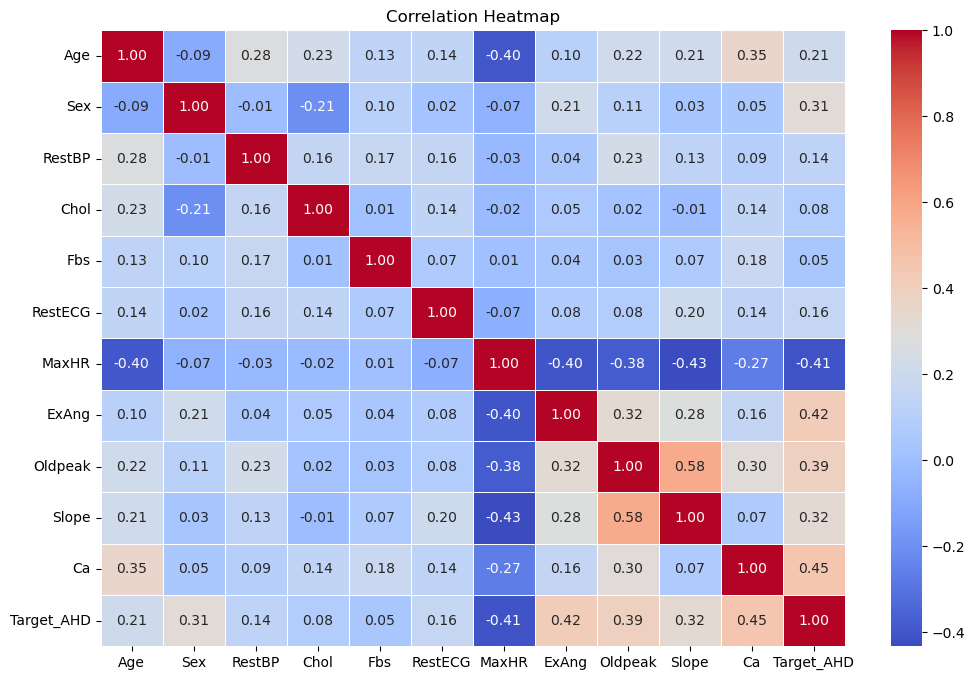

In [9]:
# a heatmap to see the correlation between the numerical features and the target for the training set
numeric_train_df = X_train.select_dtypes(include=["int64", "float64"])
numeric_train_df["Target_AHD"] = y_train.values
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_train_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# dropping fbs because it has very low correlation with the target
X_train.drop(columns=["Fbs"], inplace=True)
X_test.drop(columns=["Fbs"], inplace=True)

In [11]:
# Processing the numerical and categorical features separately with pipelines
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy="median")),
            ('scaler', StandardScaler())
        ]), numerical_columns),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy="most_frequent")),
            ('onehot', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_columns)
    ]
)

In [12]:
#Tranforming the data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Converting the arrays back to DataFrames for better readability
feature_names = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_final = pd.DataFrame(X_test_transformed, columns=feature_names)

X_train_final.head()

,num__Age,num__Sex,num__RestBP,num__Chol,num__RestECG,num__MaxHR,num__ExAng,num__Oldpeak,num__Slope,num__Ca,cat__ChestPain_asymptomatic,cat__ChestPain_nonanginal,cat__ChestPain_nontypical,cat__ChestPain_typical,cat__Thal_fixed,cat__Thal_normal,cat__Thal_reversable
0,-0.729485,0.68313,-0.395692,0.458139,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.050166,0.68313,-0.054513,0.230598,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.061212,-1.46385,0.059213,0.723605,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.061212,0.68313,-1.305501,1.121803,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.272924,-1.46385,0.514117,-0.167601,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
# Searching for best random forest parameters for this dataset using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_final, y_train)

# best parameters combo for random forest
best_rf_params = grid_search.best_params_
print(f"Best Forest Settings: {best_rf_params}")

Best Forest Settings: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


In [16]:
# comparing the best random forest with logistic regression using cross-validation on the training set
from sklearn.model_selection import cross_validate

# the 2 models to compare
logistic_model = LogisticRegression()
ranforest_model = RandomForestClassifier(**best_rf_params, random_state=42)

# Run internal tests on the Training Set
metrics = ['accuracy', 'recall', 'f1']
log_cv = cross_validate(logistic_model, X_train_final, y_train, cv=5, scoring=metrics)
rf_cv = cross_validate(ranforest_model, X_train_final, y_train, cv=5, scoring=metrics)

# Print the results to compare
print('Cross-Validation Results for logistic regression')
print(f"All Fold Accuracies: {log_cv['test_accuracy']}")
print(f"All Fold Recalls: {log_cv['test_recall']}")
print(f"All Fold F1-Scores: {log_cv['test_f1']}")
print('The average of the 5 folds for each metric:')
print(f"LogReg -> Accuracy: {log_cv['test_accuracy'].mean():.2%}, Recall: {log_cv['test_recall'].mean():.2%}, F1-Score: {log_cv['test_f1'].mean():.2%}")

print('\nCross-Validation Results for Random Forest')
print(f"All Fold Accuracies: {rf_cv['test_accuracy']}")
print(f"All Fold Recalls: {rf_cv['test_recall']}")
print(f"All Fold F1-Scores: {rf_cv['test_f1']}")
print('The average of the 5 folds for each metric:')
print(f"Best RF -> Accuracy: {rf_cv['test_accuracy'].mean():.2%}, Recall: {rf_cv['test_recall'].mean():.2%}, F1-Score: {rf_cv['test_f1'].mean():.2%}")

Cross-Validation Results for logistic regression
All Fold Accuracies: [0.91836735 0.79591837 0.8125     0.83333333 0.79166667]
All Fold Recalls: [0.82608696 0.72727273 0.81818182 0.81818182 0.72727273]
All Fold F1-Scores: [0.9047619  0.76190476 0.8        0.81818182 0.76190476]
The average of the 5 folds for each metric:
LogReg -> Accuracy: 83.04%, Recall: 78.34%, F1-Score: 80.94%

Cross-Validation Results for Random Forest
All Fold Accuracies: [0.91836735 0.7755102  0.83333333 0.77083333 0.8125    ]
All Fold Recalls: [0.86956522 0.72727273 0.81818182 0.72727273 0.68181818]
All Fold F1-Scores: [0.90909091 0.74418605 0.81818182 0.74418605 0.76923077]
The average of the 5 folds for each metric:
Best RF -> Accuracy: 82.21%, Recall: 76.48%, F1-Score: 79.70%


In [17]:
# Logistic regression is better, now examining it
from sklearn.model_selection import cross_val_predict

# getting the predicted probabilities for the positive class using cross-validation
y_probs = cross_val_predict(logistic_model, X_train_final, y_train, cv=5, method='predict_proba')[:, 1]

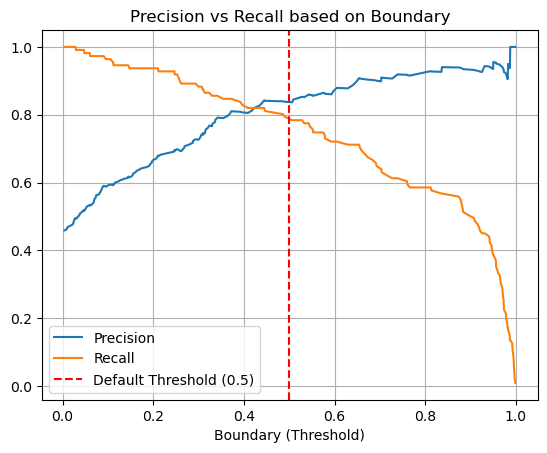

In [20]:
# looking at the precision-recall curve 
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, y_probs)
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(0.5, color='red', linestyle='--', label="Default Threshold (0.5)")
plt.grid()
plt.xlabel("Boundary (Threshold)")
plt.title("Precision vs Recall based on Boundary")
plt.legend()
plt.show()

In [25]:
# finding the threshold for 95% recall and the corresponding precision
index_95_recall = np.where(recall >= 0.95)[0][-1]
target_threshold_95 = thresholds[index_95_recall]       
print(f"Target Threshold for 95% Recall: {target_threshold_95:.4f}")
print(f"Precision at 95% Recall: {precision[index_95_recall]:.2%}")

Target Threshold for 95% Recall: 0.1120
Precision at 95% Recall: 59.55%


In [26]:
# finding the threshold for 92% recall and the corresponding precision
index_92_recall = np.where(recall >= 0.92)[0][-1]
target_threshold = thresholds[index_92_recall]
print(f"Target Threshold for 92% Recall: {target_threshold:.4f}")
print(f"Precision at 92% Recall: {precision[index_92_recall]:.2%}")

Target Threshold for 92% Recall: 0.2471
Precision at 92% Recall: 69.59%


In [27]:
# final f1 score at the target threshold
y_pred_custom = (y_probs >= target_threshold).astype(int)
final_f1 = f1_score(y_train, y_pred_custom)
print(f"Final F1 Score at Target Threshold: {final_f1:.2%}")


Final F1 Score at Target Threshold: 79.54%
